In [41]:
# 1 ST
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

Dataset Shape:
(2640, 12)

Column Names:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           264

In [42]:
# 2nd
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


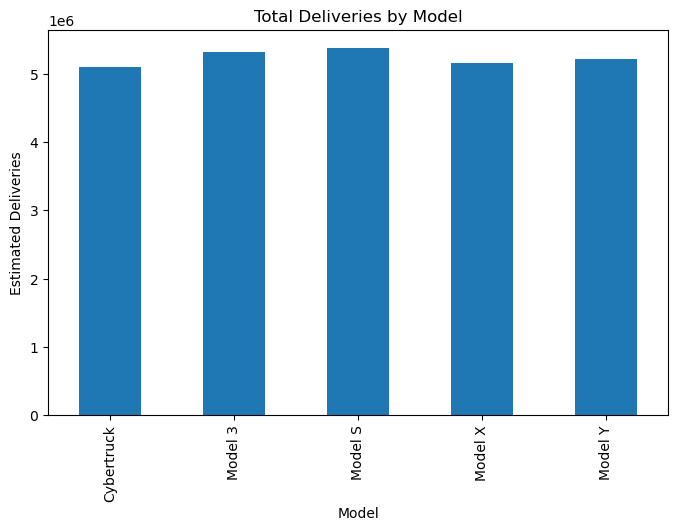

In [43]:
# 3 rd
plt.figure(figsize=(8,5))

df.groupby('Model')['Estimated_Deliveries'].sum().plot(kind='bar')

plt.title('Total Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Estimated Deliveries')

plt.show()

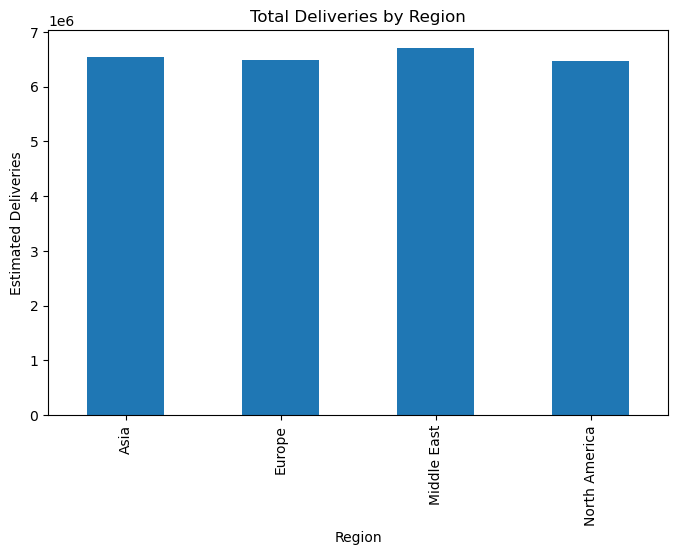

In [44]:
plt.figure(figsize=(8,5))

df.groupby('Region')['Estimated_Deliveries'].sum().plot(kind='bar')

plt.title('Total Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Estimated Deliveries')

plt.show()

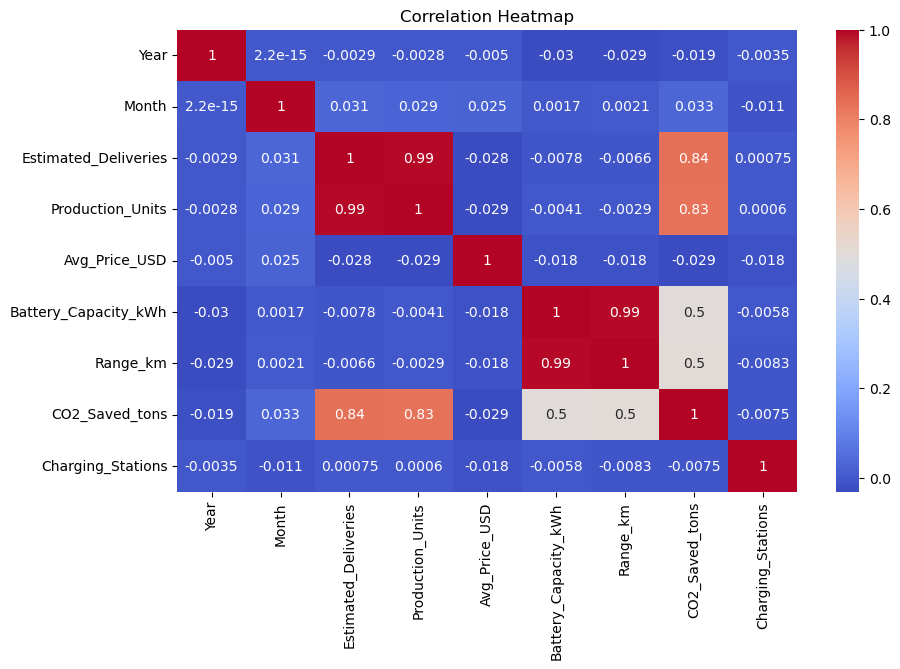

In [45]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

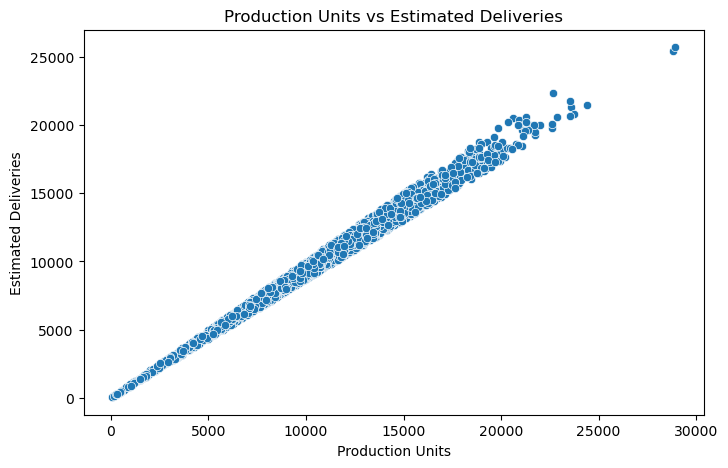

In [46]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries'
)

plt.title('Production Units vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')

plt.show()

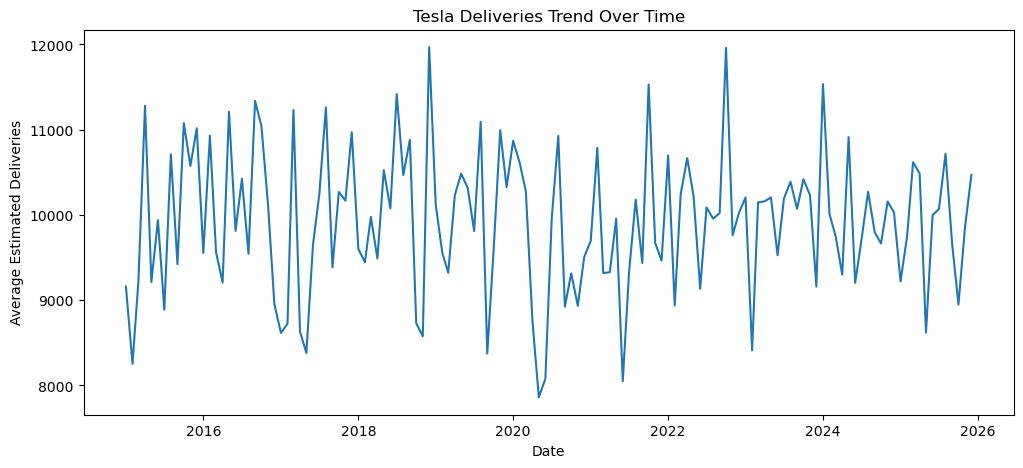

In [47]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str)
)
monthly_deliveries = df.groupby('Date')['Estimated_Deliveries'].mean()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_deliveries.index,
    monthly_deliveries.values
)

plt.title('Tesla Deliveries Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average Estimated Deliveries')

plt.show()

In [48]:
#4 th
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])


df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean()
)

df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(
    df['Rolling_Mean_3'].mean()
)



print("First 10 Records After Encoding and Feature Engineering:")
print(
    df[
        [
            'Region',
            'Model',
            'Source_Type',
            'Estimated_Deliveries',
            'Deliveries_Lag1',
            'Rolling_Mean_3'
        ]
    ].head(10)
)

print("\nDataset Shape:")
print(df.shape)

print("\nNew Columns Added:")
print(['Deliveries_Lag1', 'Rolling_Mean_3'])

First 10 Records After Encoding and Feature Engineering:
   Region  Model  Source_Type  Estimated_Deliveries  Deliveries_Lag1  \
0       1      2            1                 17646      9924.959454   
1       0      3            2                  3797     17646.000000   
2       3      3            1                  8411      3797.000000   
3       3      1            2                  6555      8411.000000   
4       2      4            0                 12374      6555.000000   
5       0      3            2                  4656     12374.000000   
6       0      1            1                  7717      4656.000000   
7       1      0            2                  8410      7717.000000   
8       1      2            1                 15145      8410.000000   
9       2      4            1                  7790     15145.000000   

   Rolling_Mean_3  
0     9923.677407  
1     9923.677407  
2     9951.333333  
3     6254.333333  
4     9113.333333  
5     7861.666667  
6     8249

In [49]:
X = df.drop(columns=['Estimated_Deliveries'])

y = df['Estimated_Deliveries']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2640, 14)
y Shape: (2640,)


In [50]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Size:", len(X_train))
print("Testing Size :", len(X_test))

Training Size: 2112
Testing Size : 528


Training Records: 2112
Testing Records : 528

===== Linear Regression Performance =====
MAE : 310.33
RMSE: 375.56
R²  : 0.9908


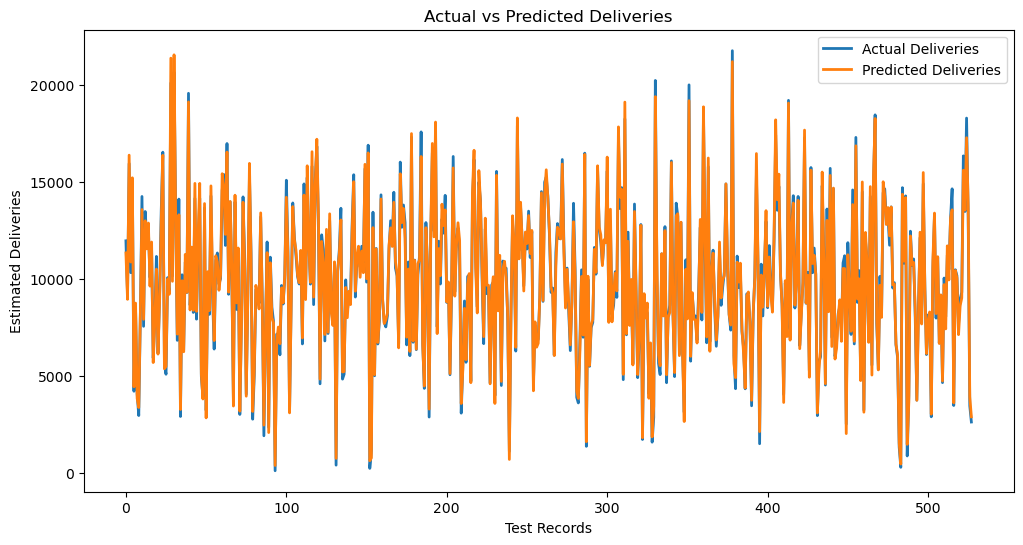

In [51]:
# 5 th
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

X = df.drop(columns=['Estimated_Deliveries', 'Date'])

y = df['Estimated_Deliveries']


split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Records:", len(X_train))
print("Testing Records :", len(X_test))



lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)



mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("\n===== Linear Regression Performance =====")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))



plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Deliveries',
    linewidth=2
)

plt.plot(
    y_pred,
    label='Predicted Deliveries',
    linewidth=2
)

plt.title('Actual vs Predicted Deliveries')
plt.xlabel('Test Records')
plt.ylabel('Estimated Deliveries')

plt.legend()

plt.show()

In [52]:
# 6th
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = df.drop(columns=['Estimated_Deliveries', 'Date'])
y = df['Estimated_Deliveries']

lr = LinearRegression()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print("R² Score for Each Fold:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R² Score:")
print(round(np.mean(cv_scores), 4))

R² Score for Each Fold:
Fold 1: 0.9902
Fold 2: 0.9909
Fold 3: 0.9907
Fold 4: 0.9899
Fold 5: 0.9901

Mean R² Score:
0.9904


Best Parameters:
{'max_depth': None, 'n_estimators': 50}

===== Random Forest Performance =====
MAE : 303.86
RMSE: 388.55
R²  : 0.9902

Top 10 Important Features:
              Feature  Importance
4    Production_Units    0.990055
8      CO2_Saved_tons    0.002163
7            Range_km    0.001221
5       Avg_Price_USD    0.001040
10  Charging_Stations    0.001004
12     Rolling_Mean_3    0.000955
11    Deliveries_Lag1    0.000923
0                Year    0.000888
1               Month    0.000668
3               Model    0.000357


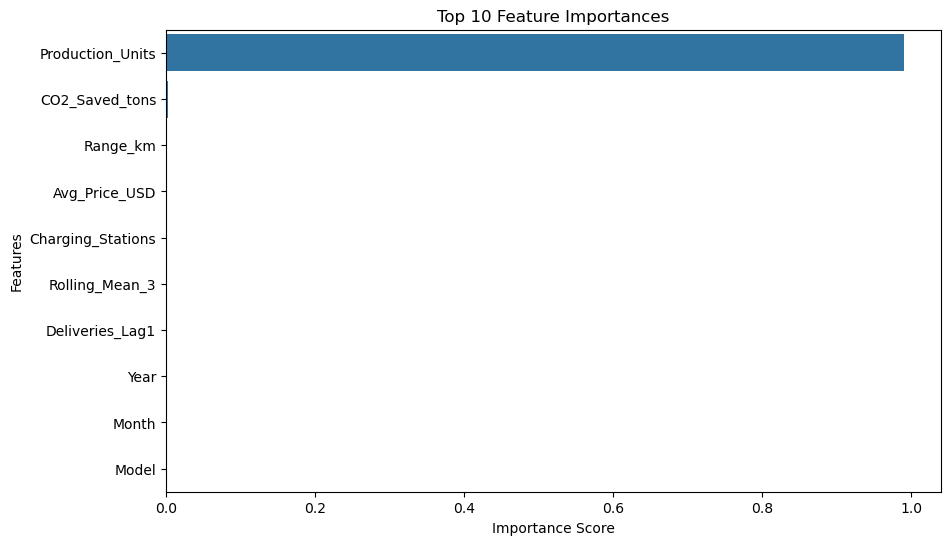

In [53]:
# 7th
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


X = df.drop(columns=['Estimated_Deliveries', 'Date'])
y = df['Estimated_Deliveries']



split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

rf = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)



rf_pred = best_rf.predict(X_test)


mae = mean_absolute_error(y_test, rf_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

r2 = r2_score(y_test, rf_pred)

print("\n===== Random Forest Performance =====")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))



feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top10 = feature_importance.head(10)

print("\nTop 10 Important Features:")
print(top10)



plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

In [55]:
# 8th
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("No. of Lags   :", adf_result[2])
print("Observations  :", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

p_value = adf_result[1]

if p_value < 0.05:
    print("Conclusion: The series is STATIONARY.")
    print("Since p-value < 0.05, we reject the null hypothesis.")
else:
    print("Conclusion: The series is NON-STATIONARY.")
    print("Since p-value >= 0.05, we fail to reject the null hypothesis.")

ADF Statistic : -53.826612597156206
p-value       : 0.0
No. of Lags   : 0
Observations  : 2639

Critical Values:
1%: -3.432830360798943
5%: -2.8626358355986774
10%: -2.5673533514279425
Conclusion: The series is STATIONARY.
Since p-value < 0.05, we reject the null hypothesis.


In [56]:
# 9th
forecast_table = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': rf_pred[:20]
})

forecast_table['Error_%'] = (
    abs(
        forecast_table['Actual']
        - forecast_table['Predicted']
    )
    / forecast_table['Actual']
) * 100

forecast_table = forecast_table.round(2)

print("Forecast Comparison Table (First 20 Test Records)")
forecast_table

Forecast Comparison Table (First 20 Test Records)


,Actual,Predicted,Error_%
0,11974,11244.76,6.09
1,9189,8947.18,2.63
2,15956,16791.60,5.24
3,10336,10896.56,5.42
4,15152,15868.72,4.73
5,4224,4014.38,4.96
6,8475,8863.10,4.58
7,4093,3817.50,6.73
8,2972,3149.94,5.99
9,8208,8202.68,0.06
